In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
daily = pd.read_csv('../data/processed/daily_features.csv', parse_dates=['ActivityDate'])
worn = daily[daily['is_worn']]

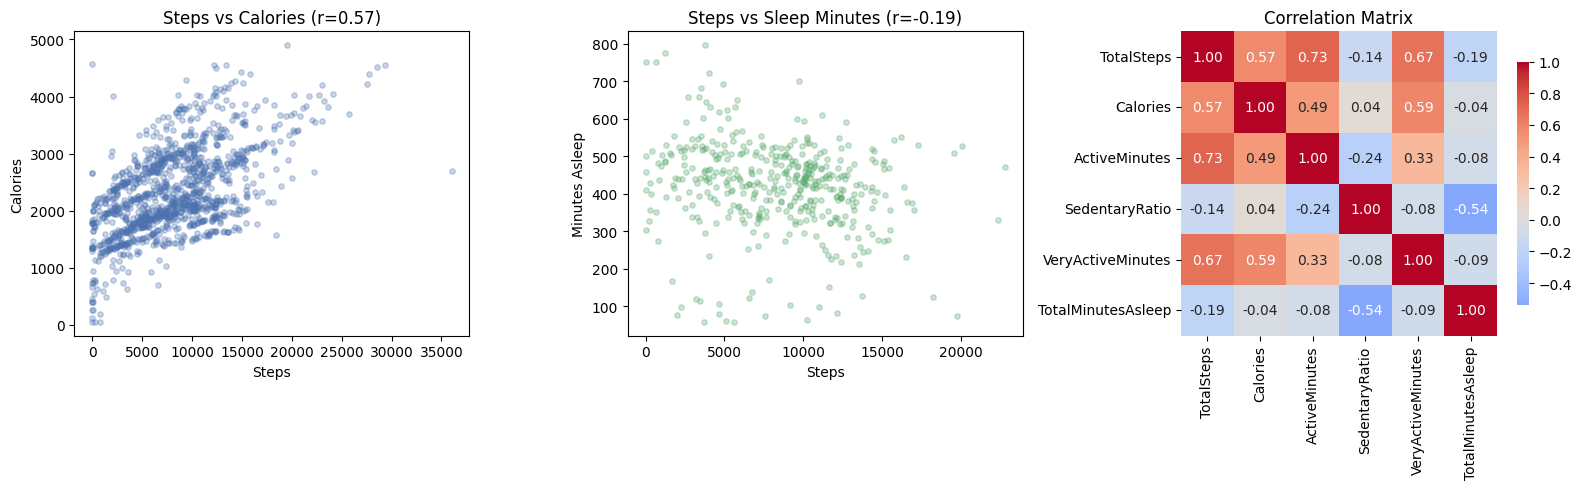

r(steps,calories)= 0.57  r(steps,sleep)= -0.194
r(SedentaryRatio, TotalMinutesAsleep)= -0.541


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(worn['TotalSteps'], worn['Calories'], alpha=0.3, s=15, color='#4C72B0')
r1 = worn['TotalSteps'].corr(worn['Calories'])
axes[0].set_title(f'Steps vs Calories (r={r1:.2f})')
axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Calories')

sleep_df = worn.dropna(subset=['TotalMinutesAsleep'])
axes[1].scatter(sleep_df['TotalSteps'], sleep_df['TotalMinutesAsleep'], alpha=0.3, s=15, color='#55A868')
r2 = sleep_df['TotalSteps'].corr(sleep_df['TotalMinutesAsleep'])
axes[1].set_title(f'Steps vs Sleep Minutes (r={r2:.2f})')
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('Minutes Asleep')

cols = ['TotalSteps','Calories','ActiveMinutes','SedentaryRatio','VeryActiveMinutes','TotalMinutesAsleep']
corr = worn[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[2], cbar_kws={'shrink':0.8})
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('../outputs/figures/02_correlations.png', dpi=130)
plt.show()

print('r(steps,calories)=', round(r1,3), ' r(steps,sleep)=', round(r2,3))
print('r(SedentaryRatio, TotalMinutesAsleep)=', round(corr.loc['SedentaryRatio','TotalMinutesAsleep'],3))